# NAIP Inference — Occupancy as Fraction of Total Image

Same model and images as `naip_inference.ipynb`, but with a different occupancy metric:

| Metric | Formula |
|---|---|
| Previous | `occupied_pixels / (empty + occupied)` — fraction of detected parking spaces |
| **This notebook** | `occupied_pixels / total_pixels` — fraction of the whole image footprint |

The new metric captures how large the occupied area is relative to the full image, regardless of how much background is present.

## 1 · Setup

In [1]:
import re
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from albumentations.pytorch import ToTensorV2
from PIL import Image
import segmentation_models_pytorch as smp

DATA_ROOT      = Path("../Data")
NAIP_DIR       = DATA_ROOT / "naip_images"
CHECKPOINT_DIR = Path("../checkpoints")
OUTPUT_CSV     = DATA_ROOT / "naip_occupancy_pixel_ratio.csv"

FT_CKPT   = CHECKPOINT_DIR / "resnet34_unet_walmart_ft.pth"
BASE_CKPT = CHECKPOINT_DIR / "resnet34_unet_best.pth"
CKPT_PATH = FT_CKPT if FT_CKPT.exists() else BASE_CKPT

IMG_SIZE      = 256
IN_CHANNELS   = 3
NUM_CLASSES   = 3
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

CLASS_COLORS = np.array([
    [0,   0,   0  ],
    [0,   200, 0  ],
    [220, 50,  50 ],
], dtype=np.uint8)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
ckpt_label = "fine-tuned" if CKPT_PATH == FT_CKPT else "base PKLot (fine-tuned not found)"
print(f"Device     : {DEVICE}")
print(f"Checkpoint : {CKPT_PATH.name}  ({ckpt_label})")

Device     : mps
Checkpoint : resnet34_unet_walmart_ft.pth  (fine-tuned)


In [2]:
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = None,
    in_channels     = IN_CHANNELS,
    classes         = NUM_CLASSES,
    activation      = None,
)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model = model.to(DEVICE).eval()
print("Model ready.")

Model ready.


## 2 · Run Inference on All Images

**Occupancy** = `occupied_pixels / total_pixels`  
i.e. the share of the full image footprint predicted as occupied parking space.

In [3]:
all_paths = sorted(NAIP_DIR.glob("*.png"))
print(f"Found {len(all_paths)} images in {NAIP_DIR}")

records = []
for p in all_paths:
    m = re.match(r"^(\d+)_(\d{4}-\d{2}-\d{2})", p.stem)
    if m:
        records.append({"path": p, "store_id": int(m.group(1)), "date": m.group(2)})

print(f"Parsed : {len(records)} images")

Found 559 images in ../Data/naip_images
Parsed : 559 images


In [4]:
preprocess = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

def infer(path: Path):
    """Returns (orig_array, mask_array, occupancy_pixel_ratio)."""
    orig    = np.array(Image.open(path).convert("RGB"))
    h, w    = orig.shape[:2]
    resized = np.array(Image.fromarray(orig).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    tensor  = preprocess(image=resized)["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    mask = np.array(Image.fromarray(pred).resize((w, h), Image.NEAREST))

    # ── new metric: occupied / total pixels ────────────────────────────────
    occupancy = int((mask == 2).sum()) / mask.size
    return orig, mask, occupancy


rows   = []
images = []   # keep (orig, mask, occ) for the example plot
n      = len(records)
print(f"Running inference on {n} images …")

for i, rec in enumerate(records, 1):
    orig, mask, occ = infer(rec["path"])
    rows.append({"store_id": rec["store_id"], "date": rec["date"], "occupancy": occ})
    images.append({**rec, "orig": orig, "mask": mask, "occ": occ})
    if i % 50 == 0 or i == n:
        print(f"  [{i:>3}/{n}]  store={rec['store_id']}  {rec['date']}  occ={occ:.4f}")

print("\nDone.")

Running inference on 559 images …
  [ 50/559]  store=1530  2017-07-02  occ=0.0823
  [100/559]  store=1903  2021-11-06  occ=0.0581
  [150/559]  store=2424  2023-05-25  occ=0.0959
  [200/559]  store=2728  2022-07-11  occ=0.0703
  [250/559]  store=3047  2021-11-13  occ=0.0759
  [300/559]  store=3276  2012-07-13  occ=0.0369
  [350/559]  store=3551  2022-04-30  occ=0.0458
  [400/559]  store=380  2021-11-16  occ=0.0206
  [450/559]  store=4132  2010-07-27  occ=0.0497
  [500/559]  store=528  2010-08-29  occ=0.0425
  [550/559]  store=874  2023-07-29  occ=0.0213
  [559/559]  store=938  2023-07-30  occ=0.0122

Done.


In [5]:
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows → {OUTPUT_CSV.resolve()}\n")
df.head(10)

Saved 559 rows → /Users/felipe/Documents/BSE/Term-3/Deeplearning/Application-of-Deep-learning-image/Data/naip_occupancy_pixel_ratio.csv



,store_id,date,occupancy,year
0,42,2012-06-22,0.045929,2012
1,42,2015-08-20,0.030685,2015
2,42,2023-06-06,0.015762,2023
3,111,2012-06-25,0.027908,2012
4,111,2014-07-05,0.030075,2014
5,111,2018-11-28,0.015640,2018
6,111,2021-10-18,0.036758,2021
7,111,2023-08-26,0.028915,2023
8,115,2010-08-09,0.024048,2010
9,115,2013-08-07,0.012054,2013


## 3 · Average Occupancy per Year

  Year    Mean occ       Std      N
────────────────────────────────────
  2010       4.94%     2.42%     45
  2011       4.88%     2.51%     37
  2012       3.64%     1.71%     35
  2013       3.64%     2.28%     44
  2014       4.02%     2.11%     32
  2015       3.82%     2.39%     40
  2016       3.85%     2.17%     34
  2017       4.45%     3.20%     38
  2018       4.59%     2.79%     44
  2019       5.12%     2.44%     32
  2020       4.19%     1.86%     27
  2021       4.83%     2.12%     48
  2022       5.23%     1.98%     40
  2023       3.40%     2.03%     63


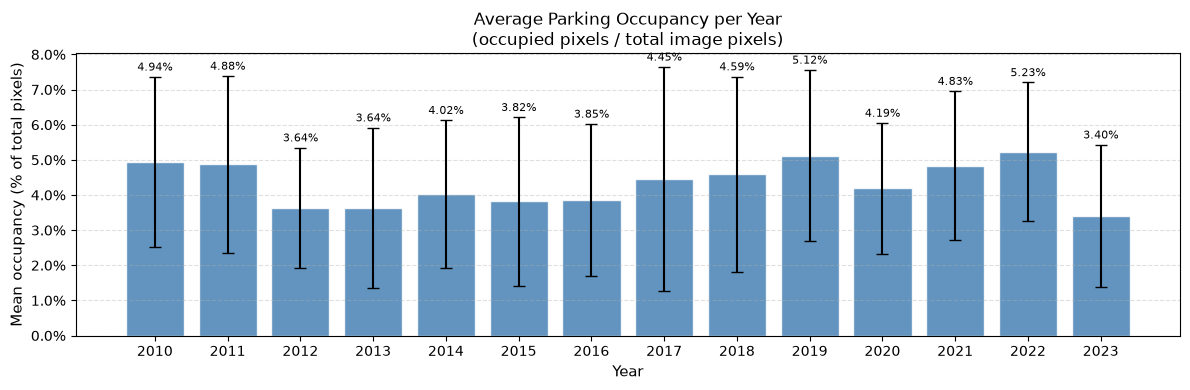

In [6]:
avg = (
    df.groupby("year")["occupancy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
avg["mean_pct"] = avg["mean"] * 100
avg["std_pct"]  = avg["std"]  * 100

print(f"{'Year':>6}  {'Mean occ':>10}  {'Std':>8}  {'N':>5}")
print("─" * 36)
for _, r in avg.iterrows():
    print(f"{int(r.year):>6}  {r.mean_pct:>9.2f}%  {r.std_pct:>7.2f}%  {int(r.n):>5}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(avg["year"], avg["mean_pct"],
       yerr=avg["std_pct"], capsize=4,
       color="steelblue", edgecolor="white", alpha=0.85)
for x, y, s in zip(avg["year"], avg["mean_pct"], avg["std_pct"]):
    ax.text(x, y + s + 0.1, f"{y:.2f}%", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean occupancy (% of total pixels)", fontsize=11)
ax.set_title("Average Parking Occupancy per Year\n(occupied pixels / total image pixels)", fontsize=12)
ax.set_xticks(avg["year"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 4 · Year-over-Year Occupancy Variation\n\nFor each store with data in at least two years, the signed change is computed between every pair of consecutive observations: `Δ = occ(year_t) − occ(year_t−1)`. The chart shows the **mean signed Δ** across stores per year (green = increase, red = decrease) and the **mean absolute |Δ|** as a dashed line on the right axis.

  Year      Mean Δ    Mean |Δ|   N stores
──────────────────────────────────────────
  2011     -1.425%      1.425%          5
  2012     -1.327%      1.782%         27
  2013     -0.895%      2.131%         32
  2014  +    0.278%      1.204%         27
  2015     -0.105%      1.477%         38
  2016     -0.138%      1.289%         32
  2017  +    0.392%      1.594%         37
  2018  +    0.798%      1.689%         42
  2019  +    0.141%      1.527%         31
  2020     -0.720%      1.506%         27
  2021  +    0.594%      1.830%         47
  2022  +    0.860%      1.661%         36
  2023     -1.076%      1.768%         61


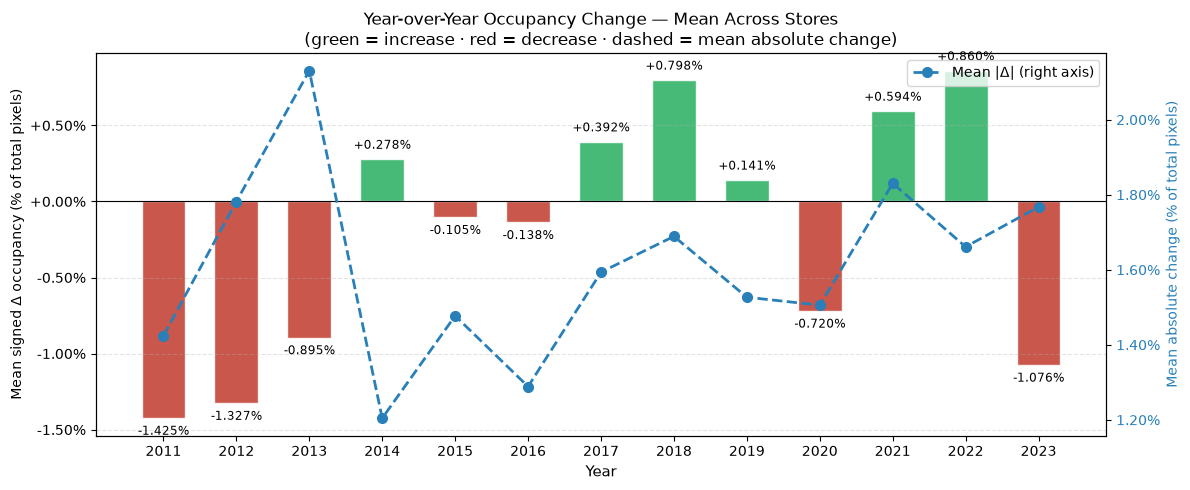

In [7]:
store_yearly = (
    df.groupby(["store_id", "year"])["occupancy"]
    .mean()
    .reset_index()
    .sort_values(["store_id", "year"])
)

delta_rows = []
for store_id, grp in store_yearly.groupby("store_id"):
    grp = grp.sort_values("year")
    if len(grp) < 2:
        continue
    for (_, prev), (_, curr) in zip(grp.iloc[:-1].iterrows(), grp.iloc[1:].iterrows()):
        delta_rows.append({
            "year_to"  : int(curr["year"]),
            "delta"    : curr["occupancy"] - prev["occupancy"],
            "abs_delta": abs(curr["occupancy"] - prev["occupancy"]),
        })

deltas = pd.DataFrame(delta_rows)

yoy = (
    deltas.groupby("year_to")
    .agg(mean_delta=("delta", "mean"), mean_abs_delta=("abs_delta", "mean"), n=("delta", "count"))
    .reset_index()
)
yoy["mean_delta_pct"]     = yoy["mean_delta"]     * 100
yoy["mean_abs_delta_pct"] = yoy["mean_abs_delta"] * 100

print(f"{'Year':>6}  {'Mean Δ':>10}  {'Mean |Δ|':>10}  {'N stores':>9}")
print("─" * 42)
for _, r in yoy.iterrows():
    sign = "+" if r.mean_delta_pct >= 0 else ""
    print(f"{int(r.year_to):>6}  {sign}{r.mean_delta_pct:>9.3f}%  {r.mean_abs_delta_pct:>9.3f}%  {int(r.n):>9}")

# ── Chart ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#27ae60" if d >= 0 else "#c0392b" for d in yoy["mean_delta_pct"]]
ax.bar(yoy["year_to"], yoy["mean_delta_pct"],
       color=colors, edgecolor="white", alpha=0.85, width=0.6)
ax.axhline(0, color="black", linewidth=0.8)

for x, y in zip(yoy["year_to"], yoy["mean_delta_pct"]):
    va  = "bottom" if y >= 0 else "top"
    off = 0.05 if y >= 0 else -0.05
    ax.text(x, y + off, f"{y:+.3f}%", ha="center", va=va, fontsize=8.5)

ax2 = ax.twinx()
ax2.plot(yoy["year_to"], yoy["mean_abs_delta_pct"],
         color="#2980b9", marker="o", linewidth=2, markersize=7,
         linestyle="--", label="Mean |Δ| (right axis)")
ax2.set_ylabel("Mean absolute change (% of total pixels)", fontsize=10, color="#2980b9")
ax2.tick_params(axis="y", labelcolor="#2980b9")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean signed Δ occupancy (% of total pixels)", fontsize=10)
ax.set_title(
    "Year-over-Year Occupancy Change — Mean Across Stores\n"
    "(green = increase · red = decrease · dashed = mean absolute change)",
    fontsize=12
)
ax.set_xticks(yoy["year_to"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.2f}%"))
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax2.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

## 5 · Example Images\n\n12 images sampled across the occupancy distribution (low → mid → high) to give a visual sense of what different occupancy values look like under the new metric.

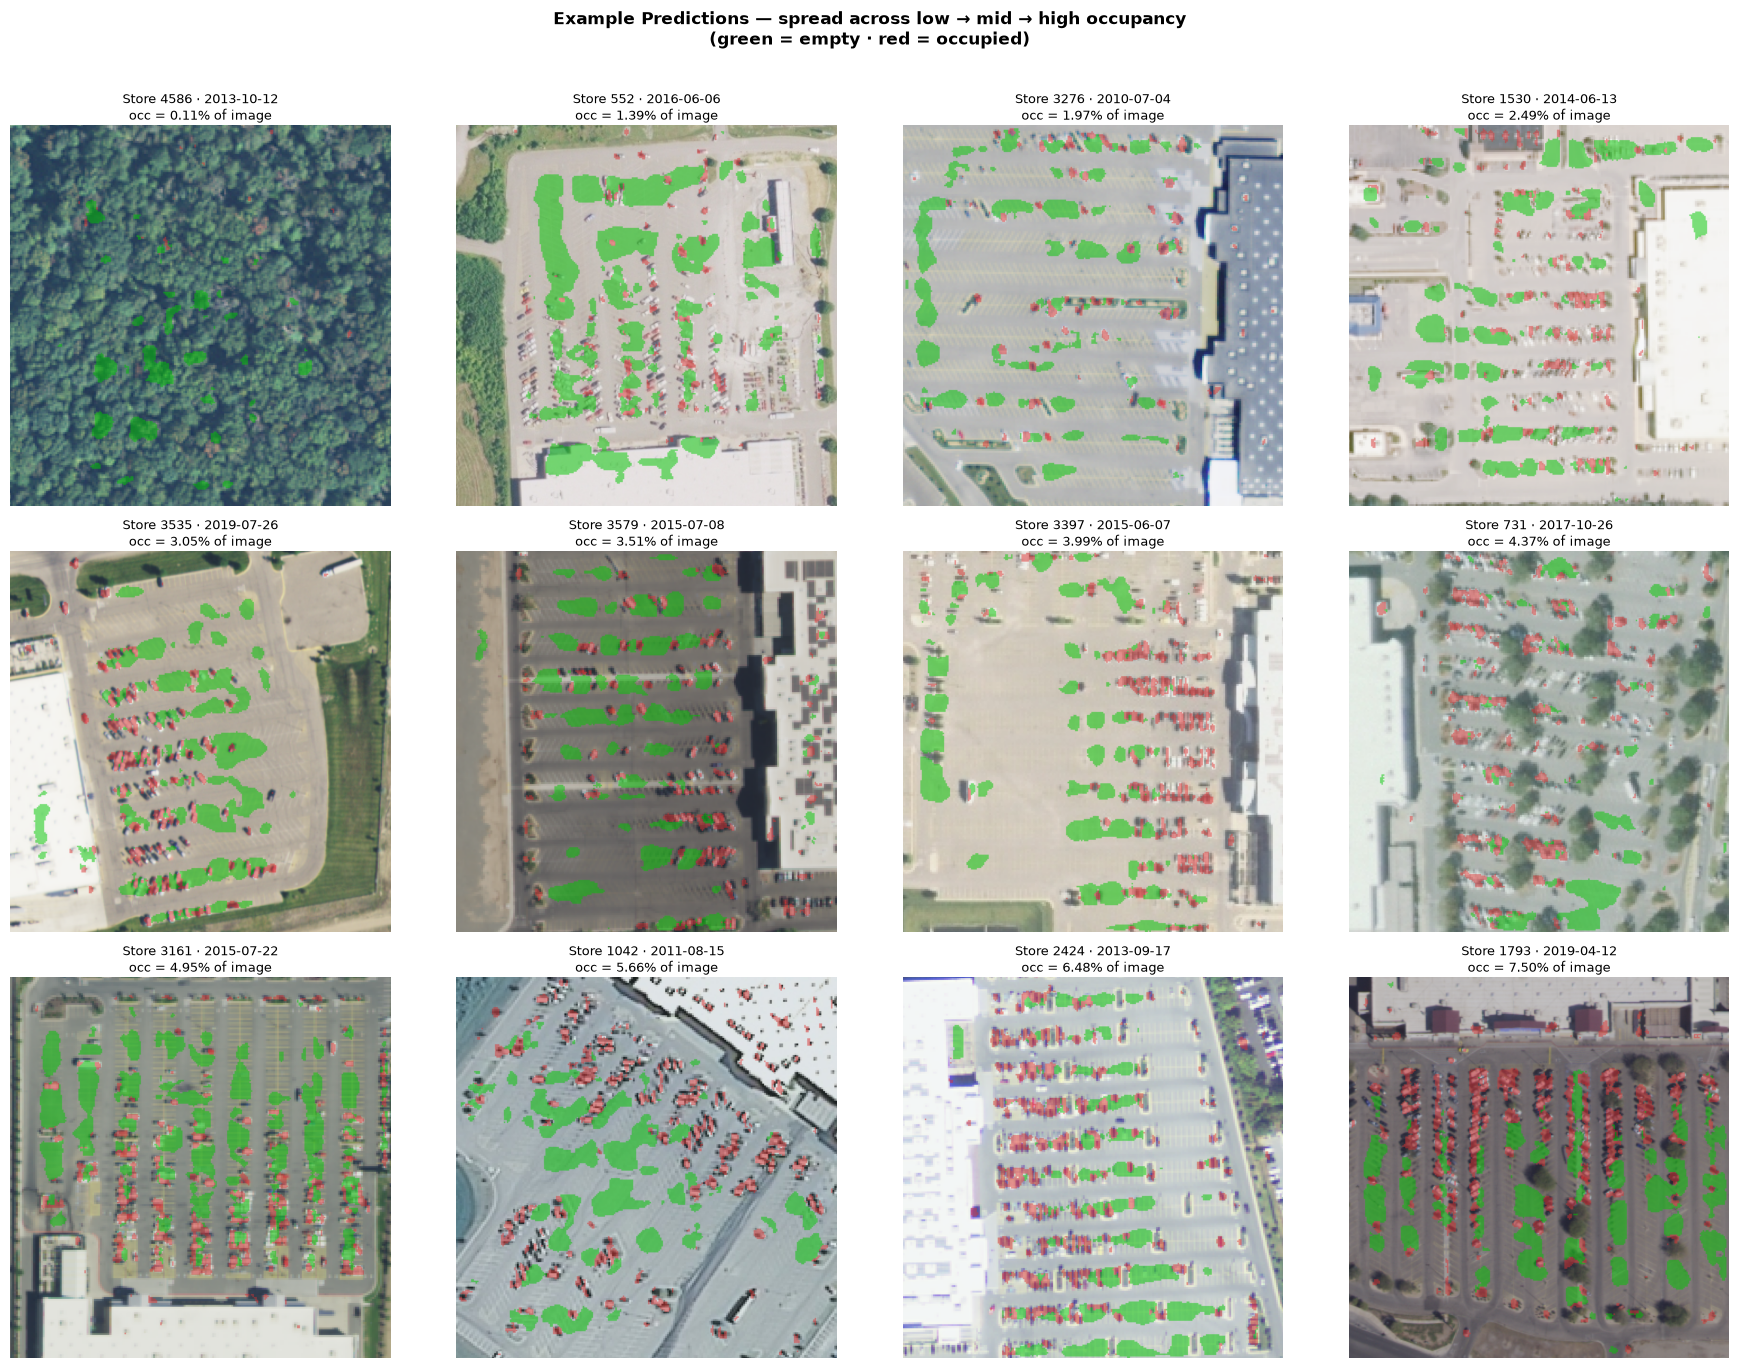

In [8]:
def make_overlay(orig: np.ndarray, mask: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    out = orig.copy().astype(float)
    for cls_id, color in enumerate(CLASS_COLORS):
        if cls_id == 0:
            continue
        where = mask == cls_id
        out[where] = out[where] * (1 - alpha) + color * alpha
    return out.astype(np.uint8)


# Pick 12 images spread across the occupancy range
N_EXAMPLES = 12
images_sorted = sorted(images, key=lambda r: r["occ"])
step          = max(1, len(images_sorted) // N_EXAMPLES)
examples      = images_sorted[::step][:N_EXAMPLES]

NCOLS = 4
NROWS = int(np.ceil(N_EXAMPLES / NCOLS))

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 4.5, NROWS * 4.5))
axes = axes.flatten()

for i, rec in enumerate(examples):
    axes[i].imshow(make_overlay(rec["orig"], rec["mask"]))
    axes[i].set_title(
        f"Store {rec['store_id']} · {rec['date']}\nocc = {rec['occ']*100:.2f}% of image",
        fontsize=9, pad=4
    )
    axes[i].axis("off")

for j in range(len(examples), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Example Predictions — spread across low → mid → high occupancy\n"
    "(green = empty · red = occupied)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()